In [ ]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import numpy as np
import pandas as pd
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
path_train = "/content/drive/MyDrive/Competitions/WISD_2025/global_challenge/processed_data/merged_train_new.csv"

train_df = pd.read_csv(path_train) # (1104, 19902)

In [ ]:
train_df

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN,...,-0.047477,-0.096450,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,...,-0.143218,-0.276464,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN,...,-0.133778,-0.108588,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0,...,-0.096647,-0.041420,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN,...,-0.158995,-0.274017,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zwjJWCRzKhDz,2019,4,1.0,1.0,3.0,12.0,NaN,15.0,5.0,...,0.157897,0.122978,0.112789,0.211312,0.601190,0.587116,0.312695,0.485938,0.189102,0.354333
1209,zwXD5v17Rx01,2018,1,0.0,0.0,3.0,21.0,40.0,21.0,40.0,...,0.343204,0.198827,0.253990,0.198741,0.648260,0.055241,0.491985,0.118676,0.404331,0.537121
1210,zWzLCi3NTBTd,2018,3,2.0,3.0,3.0,21.0,40.0,21.0,35.0,...,0.110834,-0.002346,0.044653,0.234887,0.538475,0.024265,0.472322,0.095624,0.205326,0.182633
1211,Zy9GTHDxUbXU,2019,4,0.0,1.0,3.0,18.0,35.0,18.0,45.0,...,0.013906,0.146094,-0.035955,-0.062152,0.706214,0.183288,0.104987,0.420463,0.152727,0.706737


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Columns: 19930 entries, participant_id to 198throw_199thcolumn
dtypes: float64(19925), int64(4), object(1)
memory usage: 184.4+ MB


In [ ]:
def distribution_and_percentage(df, col_name):
    # Distribution and percentage by col_name
    col_name_counts = df[col_name].value_counts()
    col_name_percentages = df[col_name].value_counts(normalize=True) * 100

    print(f"{col_name} distribution:\n{col_name_counts}")
    print(f"\n{col_name} percentage:\n{col_name_percentages}")

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    # sns.countplot(x='col_name', data=training_metadata, palette="Set1")
    sns.barplot(x=col_name_counts.index, y=col_name_counts.values, palette="Set1")
    plt.title(f'Distribution of {col_name}')
    plt.xlabel(f'{col_name}')
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    plt.pie(col_name_percentages, labels=col_name_percentages.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set1"))
    # plt.pie(col_name_percentages, labels=col_name_percentages.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'Percentage of {col_name}')

    plt.tight_layout()
    plt.show()


# age

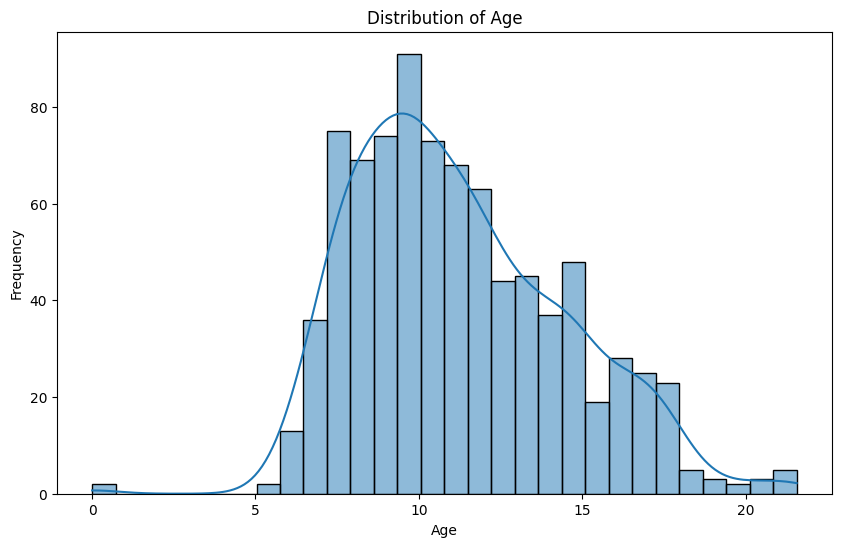

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['MRI_Track_Age_at_Scan'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# adhd

ADHD_Outcome distribution:
ADHD_Outcome
1    831
0    382
Name: count, dtype: int64

ADHD_Outcome percentage:
ADHD_Outcome
1    68.507832
0    31.492168
Name: proportion, dtype: float64


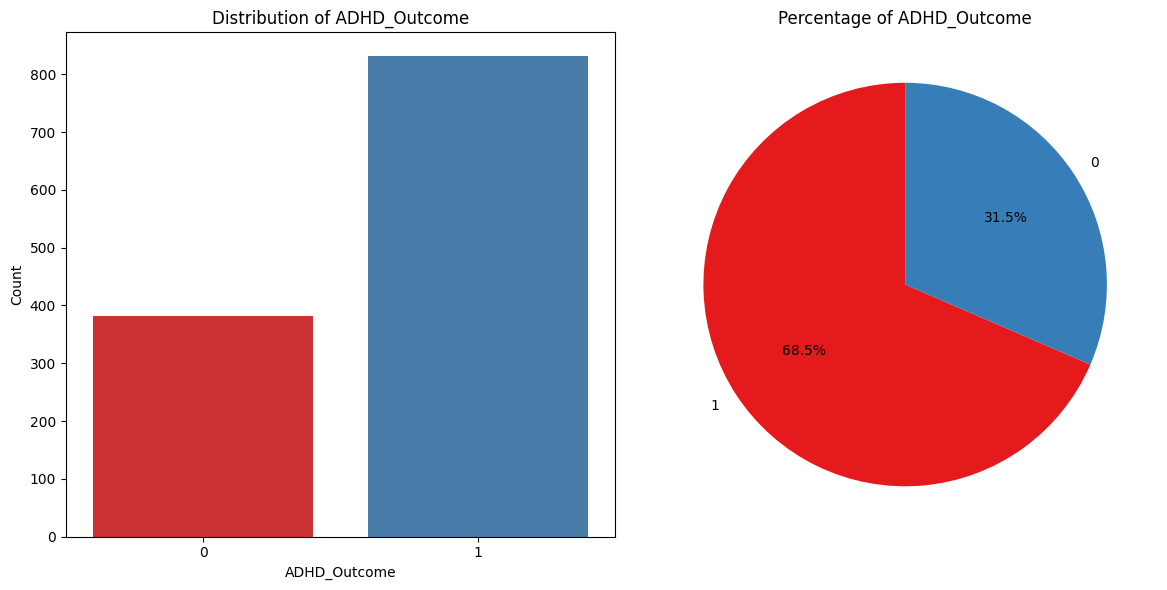

In [ ]:
distribution_and_percentage(train_df, 'ADHD_Outcome')

# sex

Sex_F distribution:
Sex_F
0    797
1    416
Name: count, dtype: int64

Sex_F percentage:
Sex_F
0    65.704864
1    34.295136
Name: proportion, dtype: float64


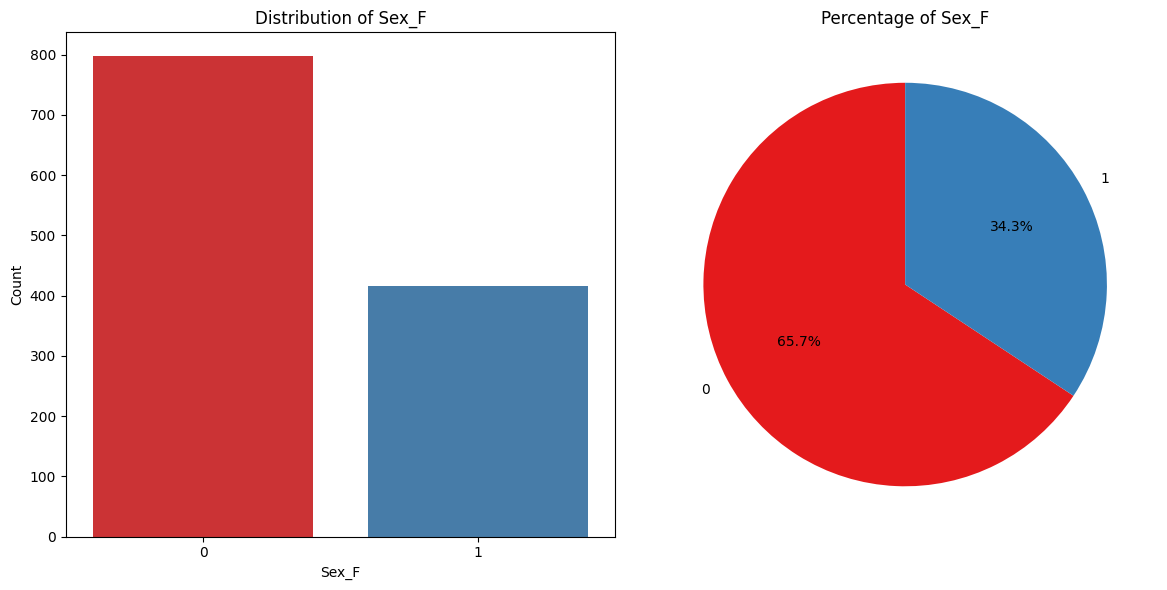

In [ ]:
distribution_and_percentage(train_df, 'Sex_F')

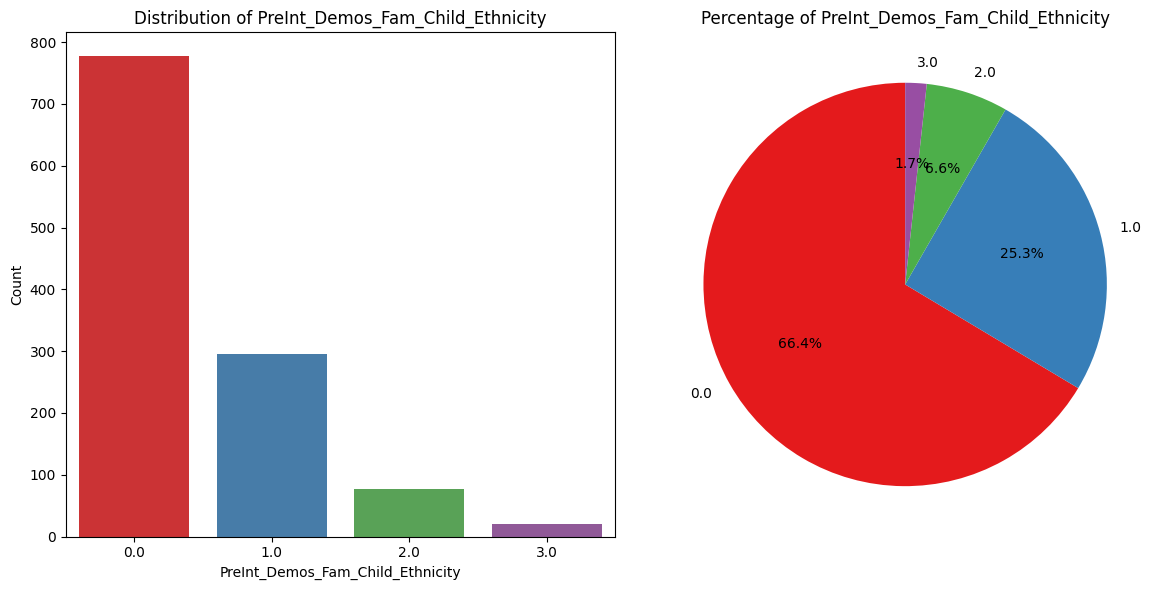

PreInt_Demos_Fam_Child_Ethnicity distribution:
PreInt_Demos_Fam_Child_Ethnicity
0.0    777
1.0    296
2.0     77
3.0     20
Name: count, dtype: int64

PreInt_Demos_Fam_Child_Ethnicity percentage:
PreInt_Demos_Fam_Child_Ethnicity
0.0    66.410256
1.0    25.299145
2.0     6.581197
3.0     1.709402
Name: proportion, dtype: float64


In [ ]:
distribution_and_percentage(train_df, 'PreInt_Demos_Fam_Child_Ethnicity')

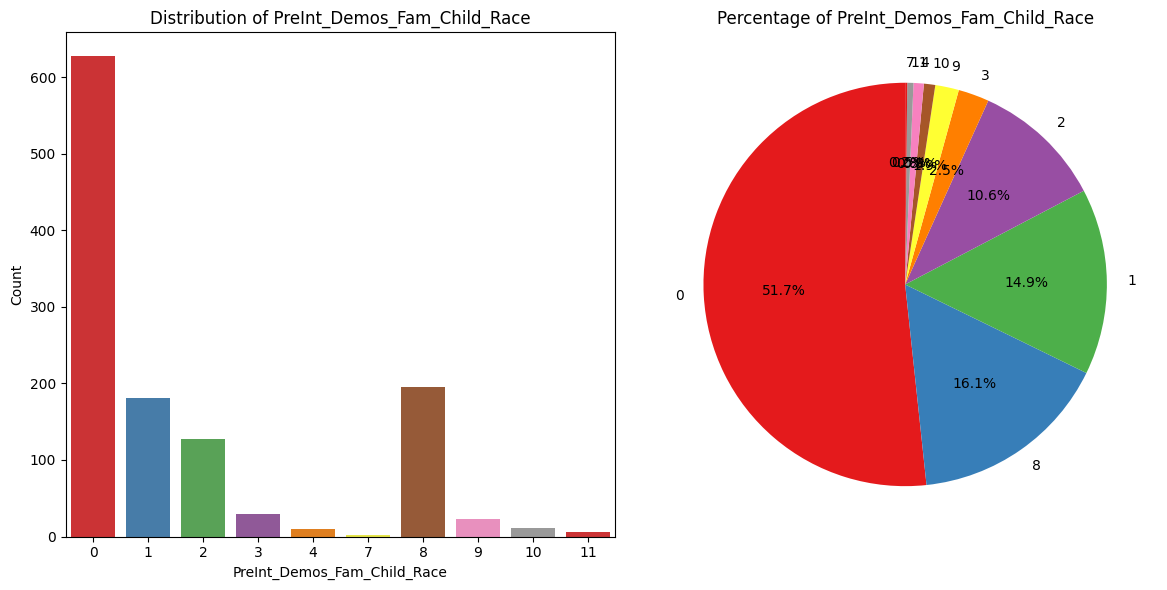

PreInt_Demos_Fam_Child_Race distribution:
PreInt_Demos_Fam_Child_Race
0     627
8     195
1     181
2     128
3      30
9      23
10     11
4      10
11      6
7       2
Name: count, dtype: int64

PreInt_Demos_Fam_Child_Race percentage:
PreInt_Demos_Fam_Child_Race
0     51.690025
8     16.075845
1     14.921682
2     10.552350
3      2.473207
9      1.896125
10     0.906843
4      0.824402
11     0.494641
7      0.164880
Name: proportion, dtype: float64


In [ ]:
distribution_and_percentage(train_df, 'PreInt_Demos_Fam_Child_Race')

# EHQ_EHQ_Total

### distribution

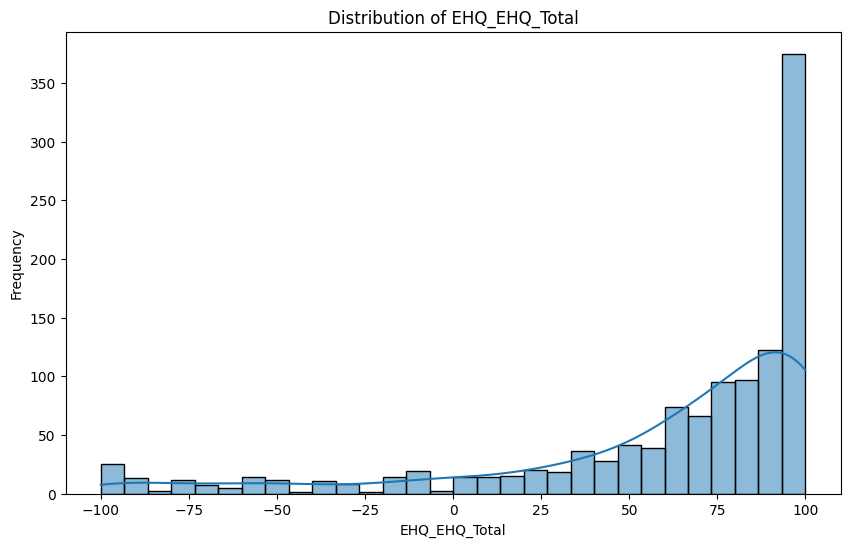

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['EHQ_EHQ_Total'], bins=30, kde=True)
plt.title('Distribution of EHQ_EHQ_Total')
plt.xlabel('EHQ_EHQ_Total')
plt.ylabel('Frequency')
plt.show()

### scatter plot

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_metadata, x='participant_id', y='p_factor_fs')
plt.title('Scatter Plot of p_factor_fs')
plt.xlabel('Participant ID')
plt.ylabel('p_factor_fs')
plt.xticks([])
# plt.xticks(rotation=90)
plt.show()

NameError: name 'train_metadata' is not defined

<Figure size 1000x600 with 0 Axes>

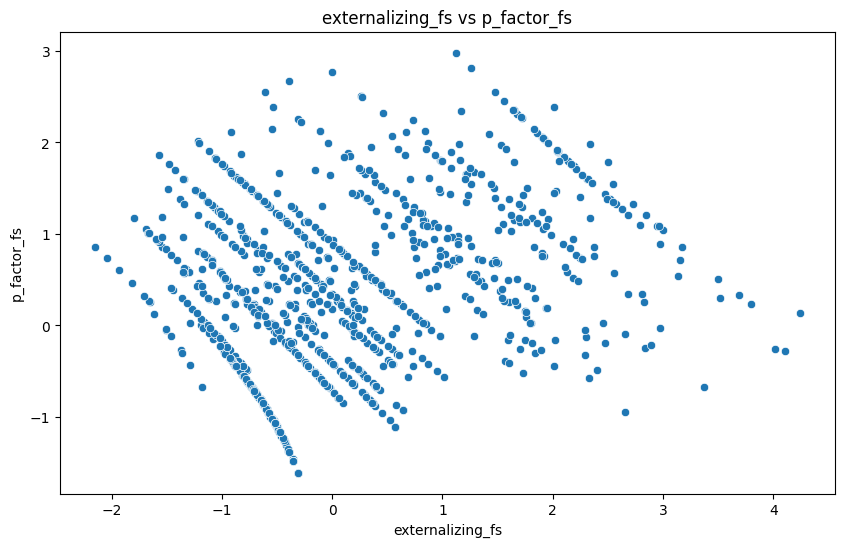

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_metadata, x='externalizing_fs', y='p_factor_fs')
plt.title('externalizing_fs vs p_factor_fs')
plt.xlabel('externalizing_fs')
plt.ylabel('p_factor_fs')
plt.show()